# Stack Overflow Developer Survey 2024: AI Sentiment Analysis

## Table of Contents

- [1. Project Overview](#1-project-overview)
- [2. Business Understanding](#2-business-understanding)
- [3. Data Source](#3-data-source)
- [4. Import Libraries](#4-import-libraries)
- [5. Load Dataset](#5-load-dataset)
- [6. Data Understanding](#6-data-understanding)
  - [6.1 Dataset Shape](#61-dataset-shape)
  - [6.2 Initial Preview](#62-initial-preview)
  - [6.3 Data Types](#63-data-types)
  - [6.4 Missing Values](#64-missing-values)
- [7. Data Preparation](#7-data-preparation)
  - [7.1 Feature Selection](#71-feature-selection)
  - [7.2 Target Variable Cleaning](#72-target-variable-cleaning)
  - [7.3 Three-Class Target Mapping](#73-three-class-target-mapping)
  - [7.4 Missing Value Strategy](#74-missing-value-strategy)
- [8. Exploratory Data Analysis](#8-exploratory-data-analysis)
  - [8.1 AI Sentiment Distribution](#81-ai-sentiment-distribution)
  - [8.2 AI Sentiment vs Coding Experience](#82-ai-sentiment-vs-coding-experience)
  - [8.3 AI Sentiment vs Trust in AI Accuracy](#83-ai-sentiment-vs-trust-in-ai-accuracy)
- [9. Modeling](#9-modeling)
  - [9.1 Feature and Target Definition](#91-feature-and-target-definition)
  - [9.2 Preprocessing Pipeline](#92-preprocessing-pipeline)
  - [9.3 Random Forest Classifier](#93-random-forest-classifier)
  - [9.4 Train/Test Split](#94-traintest-split)
- [10. Model Evaluation](#10-model-evaluation)
  - [10.1 Accuracy and Balanced Accuracy](#101-accuracy-and-balanced-accuracy)
  - [10.2 Classification Report](#102-classification-report)
  - [10.3 Confusion Matrix](#103-confusion-matrix)
- [11. Feature Importance](#11-feature-importance)
- [12. Predictive Scenario](#12-predictive-scenario)
- [13. Business Questions Answered](#13-business-questions-answered)
- [14. Conclusions](#14-conclusions)
- [15. Limitations and Future Improvements](#15-limitations-and-future-improvements)

# 1. Project Overview

This project analyzes the **2024 Stack Overflow Developer Survey** to understand how developers perceive Artificial Intelligence tools in their software development workflow.

The main objective is to explore patterns related to AI adoption, trust in AI accuracy, developer experience, and overall sentiment toward AI tools.

In addition, a machine learning model was trained to predict whether a developer is likely to have a **Negative**, **Neutral / Unsure**, or **Positive** attitude toward AI.

The project follows the **CRISP-DM** framework and includes business understanding, data understanding, data preparation, exploratory data analysis, modeling, evaluation, and a predictive scenario.

# 2. Business Understanding

Artificial Intelligence tools are becoming increasingly common in software development workflows. However, adoption does not always mean trust. Some developers may use AI tools frequently while still being skeptical about their accuracy, complexity handling, or potential impact on jobs.

The main business objective of this project is to understand what factors are associated with developer sentiment toward AI and to build a machine learning model that predicts whether a developer is likely to have a **Negative**, **Neutral / Unsure**, or **Positive** attitude toward AI tools.

This project answers the following business questions:

1. What is the overall distribution of AI sentiment among developers?
2. Does coding experience influence how developers perceive AI?
3. Is trust in AI accuracy related to positive AI sentiment?
4. Which features are most important for predicting AI sentiment?
5. What happens in a creative predictive scenario using the trained model?

# 3. Data Source

The dataset used in this project comes from the **Stack Overflow Developer Survey 2024**, using the prepared TidyTuesday version.

The files used in this project are:

- `stackoverflow_survey_single_response.csv`
- `qname_levels_single_response_crosswalk.csv`
- `stackoverflow_survey_questions.csv`

The target variable used in the analysis is:

```text
ai_sent
```

This variable represents developer sentiment toward using AI tools as part of the development workflow.

# 4. Import Libraries

In this section, the required Python libraries are imported.

The project uses:

- `pandas` and `numpy` for data manipulation.
- `matplotlib` and `seaborn` for visualization.
- `scikit-learn` for preprocessing, modeling, and evaluation.

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Create images folder if it does not exist
os.makedirs("images", exist_ok=True)

# 5. Load Dataset

In this section, the Stack Overflow Developer Survey 2024 dataset is loaded from the prepared TidyTuesday source.

Three files are loaded:

- Main survey dataset.
- Crosswalk file with encoded category labels.
- Questions file with survey question descriptions.

In [2]:
survey_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-09-03/stackoverflow_survey_single_response.csv"
crosswalk_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-09-03/qname_levels_single_response_crosswalk.csv"
questions_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-09-03/stackoverflow_survey_questions.csv"

survey_df = pd.read_csv(survey_url)
crosswalk_df = pd.read_csv(crosswalk_url)
questions_df = pd.read_csv(questions_url)

print("Survey shape:", survey_df.shape)
print("Crosswalk shape:", crosswalk_df.shape)
print("Questions shape:", questions_df.shape)

Survey shape: (65437, 28)
Crosswalk shape: (122, 3)
Questions shape: (24, 2)


# 6. Data Understanding

This section explores the structure and quality of the dataset.

The goal is to understand the number of rows and columns, available variables, data types, missing values, and initial distribution of relevant variables.

## 6.1 Dataset Shape

The dataset shape is checked to understand the number of observations and variables available for analysis.

In [3]:
survey_df.shape

(65437, 28)

## 6.2 Initial Preview

The first rows of the dataset are displayed to inspect the structure of the data and understand how the variables are represented.

In [4]:
survey_df.head()

,response_id,main_branch,age,remote_work,ed_level,years_code,years_code_pro,dev_type,org_size,purchase_influence,buildvs_buy,country,currency,comp_total,so_visit_freq,so_account,so_part_freq,so_comm,ai_select,ai_sent,ai_acc,ai_complex,ai_threat,survey_length,survey_ease,converted_comp_yearly,r_used,r_want_to_use
0,1,1,8,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,3,3.0,2.0,20.0,17.0,16.0,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,5.0,3.0,6.0,5.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,3,1,4,3.0,3.0,37.0,27.0,10.0,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,5.0,3.0,6.0,5.0,1.0,NaN,NaN,NaN,NaN,1.0,2.0,NaN,0.0,0.0
3,4,2,1,NaN,7.0,4.0,NaN,16.0,NaN,NaN,NaN,Canada,NaN,NaN,3.0,1.0,NaN,3.0,3.0,5.0,5.0,1.0,2.0,2.0,2.0,NaN,0.0,0.0
4,5,1,1,NaN,6.0,9.0,NaN,16.0,NaN,NaN,NaN,Norway,NaN,NaN,5.0,3.0,6.0,5.0,1.0,NaN,NaN,NaN,NaN,3.0,2.0,NaN,0.0,0.0


## 6.3 Data Types

The data types of each column are reviewed to identify numerical, categorical, and encoded variables.

In [5]:
survey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   response_id            65437 non-null  int64  
 1   main_branch            65437 non-null  int64  
 2   age                    65437 non-null  int64  
 3   remote_work            54806 non-null  float64
 4   ed_level               60784 non-null  float64
 5   years_code             59869 non-null  float64
 6   years_code_pro         51610 non-null  float64
 7   dev_type               59445 non-null  float64
 8   org_size               47480 non-null  float64
 9   purchase_influence     47406 non-null  float64
 10  buildvs_buy            43358 non-null  float64
 11  country                58930 non-null  object 
 12  currency               46684 non-null  object 
 13  comp_total             33740 non-null  float64
 14  so_visit_freq          59536 non-null  float64
 15  so

## 6.4 Missing Values

Missing values are analyzed to determine which columns require cleaning or imputation before modeling.

In [6]:
missing_values = survey_df.isnull().mean().sort_values(ascending=False) * 100
missing_values.head(20)

converted_comp_yearly    64.186928
comp_total               48.438957
ai_complex               43.424974
ai_acc                   42.995553
buildvs_buy              33.740850
ai_threat                31.706833
so_part_freq             30.869386
ai_sent                  29.897459
currency                 28.658099
purchase_influence       27.554747
org_size                 27.441661
years_code_pro           21.130247
remote_work              16.246160
r_want_to_use            14.800495
survey_length            14.143375
survey_ease              14.057796
country                   9.943916
so_comm                   9.587848
dev_type                  9.156899
so_visit_freq             9.017834
dtype: float64

# 7. Data Preparation

This section prepares the dataset for exploratory analysis and machine learning.

The main preparation steps include feature selection, target cleaning, three-class target mapping, and missing value strategy definition.

## 7.1 Feature Selection

A subset of relevant variables was selected based on the project objective.

The selected features include demographic variables, developer experience variables, Stack Overflow usage variables, and AI-related perception variables.

In [7]:
selected_columns = [
    "age", "remote_work", "ed_level", "years_code", "years_code_pro",
    "dev_type", "org_size", "so_visit_freq", "so_account", "ai_select",
    "ai_acc", "ai_complex", "ai_threat", "ai_sent"
]

df_raw = survey_df[selected_columns].copy()
df_raw.shape

(65437, 14)

## 7.2 Target Variable Cleaning

Rows with missing values in the target variable `ai_sent` were removed because supervised machine learning requires a known target label for each training observation.

In [8]:
df_raw = df_raw.dropna(subset=["ai_sent"]).copy()
print("Shape after removing missing target:", df_raw.shape)

Shape after removing missing target: (45873, 14)


In [9]:
class_counts = df_raw["ai_sent"].value_counts().sort_index()
class_percentages = (class_counts / class_counts.sum() * 100).round(2)

print("Class counts:\n", class_counts)
print("\nClass percentages (%):\n", class_percentages)

Class counts:
 ai_sent
1.0    22167
2.0     8564
3.0     2381
4.0     1357
5.0    10848
6.0      556
Name: count, dtype: int64

Class percentages (%):
 ai_sent
1.0    48.32
2.0    18.67
3.0     5.19
4.0     2.96
5.0    23.65
6.0     1.21
Name: count, dtype: float64


## 7.3 Three-Class Target Mapping

The original AI sentiment variable contained six categories. To make the results easier to interpret for a non-technical audience, the target variable was grouped into three broader classes:

```text
0 = Negative
1 = Neutral / Unsure
2 = Positive
```

This transformation improves interpretability and simplifies the classification problem.

In [ ]:
def map_to_3_classes(v):
    """
    Map the original six-category AI sentiment label into three broader classes.

    Parameters
    ----------
    v : int
        Original encoded AI sentiment value from the Stack Overflow Developer Survey.

    Returns
    -------
    int
        Three-class AI sentiment label:
        0 = Negative
        1 = Neutral / Unsure
        2 = Positive

    Notes
    -----
    The original target variable contains six encoded sentiment categories.
    Grouping them into three broader classes improves interpretability for
    non-technical audiences and simplifies the classification task.
    """
    if v in [1, 5]:
        return 2  # Positive
    if v in [2, 4]:
        return 1  # Neutral / Unsure
    return 0      # Negative

## 7.4 Missing Value Strategy

Missing values were handled using a preprocessing pipeline.

A `ColumnTransformer` was used to apply different imputation strategies:

- Mean imputation for continuous numeric variables.
- Most frequent imputation for encoded categorical / ordinal variables.

This approach helps avoid data leakage and keeps preprocessing integrated with the machine learning workflow.

# 8. Exploratory Data Analysis

This section explores relationships between AI sentiment and relevant developer characteristics.

The EDA focuses on distribution of AI sentiment, relationship with coding experience, and relationship with trust in AI accuracy.

## 8.1 AI Sentiment Distribution

This visualization shows how the original AI sentiment variable is distributed across developers.

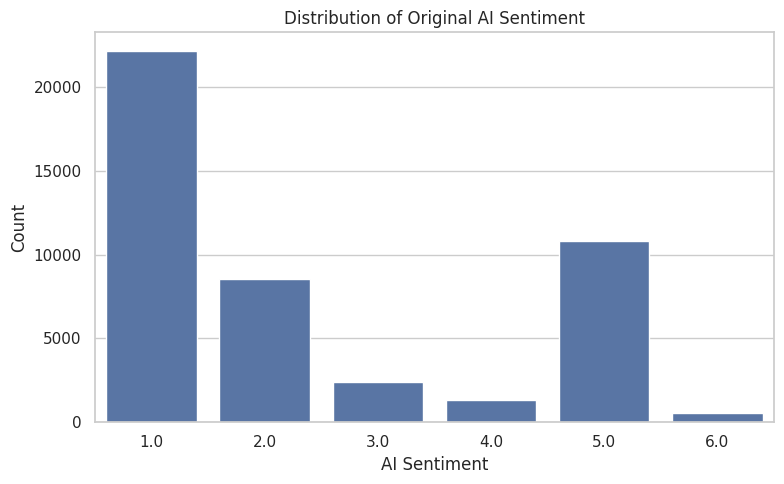

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_raw, x="ai_sent")
plt.title("Distribution of Original AI Sentiment")
plt.xlabel("AI Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/ai_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 8.2 AI Sentiment vs Coding Experience

This visualization explores whether years of coding experience vary across AI sentiment categories.

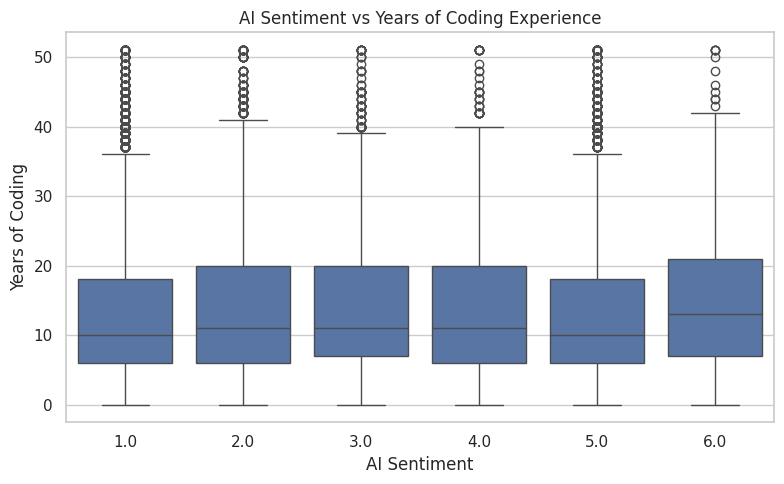

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_raw, x="ai_sent", y="years_code")
plt.title("AI Sentiment vs Years of Coding Experience")
plt.xlabel("AI Sentiment")
plt.ylabel("Years of Coding")
plt.tight_layout()
plt.savefig("images/ai_experience_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

## 8.3 AI Sentiment vs Trust in AI Accuracy

This visualization explores the relationship between AI sentiment and trust in AI accuracy.

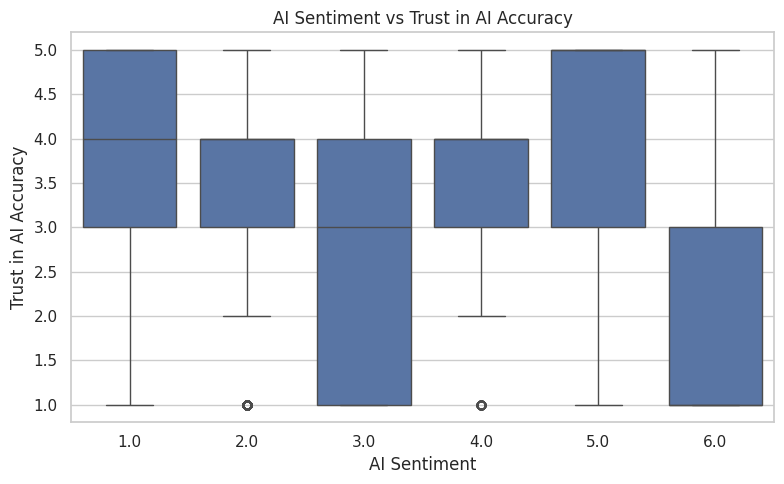

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_raw, x="ai_sent", y="ai_acc")
plt.title("AI Sentiment vs Trust in AI Accuracy")
plt.xlabel("AI Sentiment")
plt.ylabel("Trust in AI Accuracy")
plt.tight_layout()
plt.savefig("images/ai_trust_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# 9. Modeling

This section builds a machine learning model to predict developer sentiment toward AI tools.

The final model uses a **Random Forest Classifier** trained on a simplified three-class version of the AI sentiment variable.

## 9.1 Feature and Target Definition

The feature matrix `X` contains the selected explanatory variables. The target variable `y3` contains the three-class AI sentiment label.

In [14]:
X = df_raw.drop("ai_sent", axis=1)
y = df_raw["ai_sent"].astype(int)
y3 = y.apply(map_to_3_classes)

num_cols = ["years_code", "years_code_pro"]
cat_cols = [col for col in X.columns if col not in num_cols]

## 9.2 Preprocessing Pipeline

A preprocessing pipeline was created using `ColumnTransformer`.

In [15]:
preprocess_3 = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="mean"), num_cols),
        ("cat", SimpleImputer(strategy="most_frequent"), cat_cols)
    ],
    remainder="drop"
)

## 9.3 Random Forest Classifier

A Random Forest Classifier was selected because it can capture non-linear relationships and provide feature importance values.

In [16]:
rf3_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    min_samples_leaf=2,
    n_jobs=-1
)

model_3_classes = Pipeline(steps=[
    ("preprocess", preprocess_3),
    ("model", rf3_model)
])

## 9.4 Train/Test Split

The dataset was divided into training and testing sets. A stratified split was used to preserve the proportion of each sentiment class in both sets.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y3, test_size=0.2, random_state=42, stratify=y3
)

model_3_classes.fit(X_train, y_train)
y_pred3 = model_3_classes.predict(X_test)

# 10. Model Evaluation

This section evaluates the final machine learning model using accuracy, balanced accuracy, precision, recall, F1-score, and confusion matrix.

## 10.1 Accuracy and Balanced Accuracy

Accuracy measures the overall percentage of correct predictions, while balanced accuracy provides a more reliable measure when classes are imbalanced.

In [18]:
accuracy = accuracy_score(y_test, y_pred3)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred3)

print("Accuracy (3 classes):", accuracy)
print("Balanced accuracy:", balanced_accuracy)

Accuracy (3 classes): 0.6865395095367848
Balanced accuracy: 0.4910811354300921


## 10.2 Classification Report

The classification report provides precision, recall, and F1-score for each sentiment class.

In [19]:
print(classification_report(y_test, y_pred3))

              precision    recall  f1-score   support

           0       0.32      0.28      0.30       588
           1       0.37      0.37      0.37      1984
           2       0.81      0.82      0.81      6603

    accuracy                           0.69      9175
   macro avg       0.50      0.49      0.50      9175
weighted avg       0.68      0.69      0.68      9175



## 10.3 Confusion Matrix

The confusion matrix shows how many observations were correctly and incorrectly classified for each sentiment category.

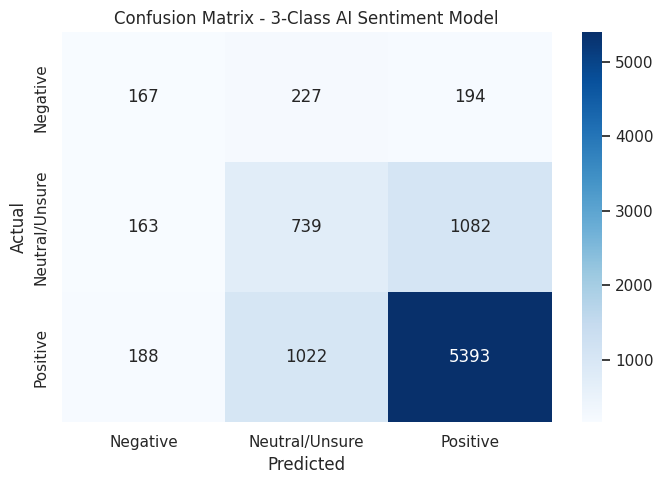

In [20]:
cm = confusion_matrix(y_test, y_pred3)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral/Unsure", "Positive"],
    yticklabels=["Negative", "Neutral/Unsure", "Positive"]
)
plt.title("Confusion Matrix - 3-Class AI Sentiment Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 11. Feature Importance

This section identifies which variables contributed most to the Random Forest model predictions.

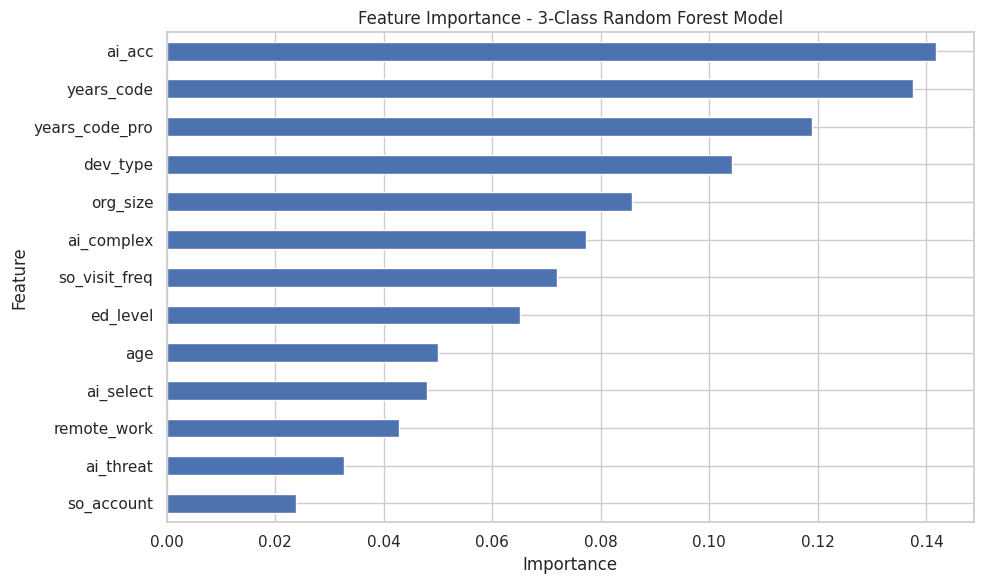

In [21]:
trained_rf3 = model_3_classes.named_steps["model"]
feature_names = num_cols + cat_cols

importances = pd.Series(
    trained_rf3.feature_importances_,
    index=feature_names
).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind="barh")
plt.title("Feature Importance - 3-Class Random Forest Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# 12. Predictive Scenario

A hypothetical developer profile was created to test the model in a practical scenario.

In [22]:
new_dev = pd.DataFrame([{
    "age": 3,
    "remote_work": 3,
    "ed_level": 4,
    "years_code": 5,
    "years_code_pro": 2,
    "dev_type": 15,
    "org_size": 3,
    "so_visit_freq": 5,
    "so_account": 3,
    "ai_select": 5,
    "ai_acc": 4,
    "ai_complex": 3,
    "ai_threat": 2
}])

prediction = model_3_classes.predict(new_dev)
label_map = {0: "Negative", 1: "Neutral / Unsure", 2: "Positive"}
print("Predicted AI Sentiment:", label_map[prediction[0]])

Predicted AI Sentiment: Positive


# 13. Business Questions Answered

## 1. What is the overall distribution of AI sentiment among developers?
Most developers in the analyzed dataset show a positive attitude toward AI tools.

## 2. Does coding experience influence how developers perceive AI?
Coding experience may influence perception, but it does not fully explain AI sentiment by itself.

## 3. Is trust in AI accuracy related to positive AI sentiment?
Yes. Developers who report higher trust in AI accuracy tend to show more favorable sentiment toward AI.

## 4. Which features are most important for predicting AI sentiment?
AI-related variables such as trust in AI accuracy, perceived complexity, and perceived threat are relevant predictors, together with developer experience and profile variables.

## 5. What happens in a creative predictive scenario?
The model predicts whether a hypothetical developer profile is more likely to have a Negative, Neutral / Unsure, or Positive attitude toward AI tools.

# 14. Conclusions

This project analyzed developer sentiment toward AI tools using the Stack Overflow Developer Survey 2024.

The analysis showed that positive sentiment toward AI is the dominant pattern among developers. Trust in AI accuracy appears to be one of the most relevant factors associated with favorable sentiment.

The final Random Forest model achieved an accuracy of approximately 68.65%. However, the balanced accuracy was lower, around 49.11%, which indicates that the model performs better on the majority class than on minority classes.

Overall, the model is useful for identifying broad AI sentiment patterns, but it should not be interpreted as a perfect individual-level predictor.

# 15. Limitations and Future Improvements

## Limitations

- The original AI sentiment variable was imbalanced.
- Some survey responses contained missing values.
- The model predicts broad sentiment categories, not exact individual opinions.
- The dataset is based on survey responses, which may include response bias.
- The model performs better on Positive sentiment than on Negative or Neutral / Unsure sentiment.

## Future Improvements

- Testing other algorithms such as Logistic Regression, Gradient Boosting, or XGBoost.
- Applying resampling techniques to improve minority class prediction.
- Using additional variables from the full Stack Overflow dataset.
- Comparing sentiment patterns across countries, developer roles, or experience levels.
- Creating an interactive dashboard to explore AI sentiment visually.
- Testing ordinal classification approaches because the original sentiment variable has an ordered structure.

In [23]:
os.listdir("images")

['ai_trust_boxplot.png',
 'feature_importance.png',
 'confusion_matrix.png',
 'ai_sentiment_distribution.png',
 'ai_experience_boxplot.png']